# LM-Eval Multiple Choice Analysis

Analysis of LM-Eval results from ARC, HellaSwag, and MMLU with 17 emotional prompts.

**Note:** These results showed minimal variance (~2-4%) which motivated the pivot to open-ended evaluation.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded!")

Libraries loaded!


## 1. Load LM-Eval Results

In [2]:
# Load all three datasets
with open('../results/lm_eval/results_arc.json', 'r') as f:
    arc_data = json.load(f)

with open('../results/lm_eval/results_hellaswag.json', 'r') as f:
    hellaswag_data = json.load(f)

with open('../results/lm_eval/results_mmlu_humanities.json', 'r') as f:
    mmlu_data = json.load(f)

print("✓ Loaded all LM-Eval results")
print(f"  ARC emotions: {len(arc_data)}")
print(f"  HellaSwag emotions: {len(hellaswag_data)}")
print(f"  MMLU emotions: {len(mmlu_data)}")

✓ Loaded all LM-Eval results
  ARC emotions: 18
  HellaSwag emotions: 18
  MMLU emotions: 15


## 2. Extract Accuracy Data

In [3]:
# Extract ARC accuracy
arc_accuracy = {}
for emotion, results in arc_data.items():
    arc_accuracy[emotion] = results['arc_challenge']['acc_norm,none']

# Extract HellaSwag accuracy
hellaswag_accuracy = {}
for emotion, results in hellaswag_data.items():
    hellaswag_accuracy[emotion] = results['hellaswag']['acc_norm,none']

# Extract MMLU accuracy (average across subjects)
mmlu_accuracy = {}
for emotion, results in mmlu_data.items():
    # Average across all subjects
    accuracies = [v['exact_match,custom-extract'] for k, v in results.items()]
    mmlu_accuracy[emotion] = np.mean(accuracies)

# Create DataFrame
df = pd.DataFrame({
    'ARC': arc_accuracy,
    'HellaSwag': hellaswag_accuracy,
    'MMLU': mmlu_accuracy
})

print("\nAccuracy DataFrame:")
print(df)


Accuracy DataFrame:
               ARC  HellaSwag   MMLU
baseline      0.55       0.70  0.394
excited       0.55       0.71  0.404
joyful        0.55       0.69  0.406
amused        0.54       0.68  0.424
enthusiastic  0.55       0.68  0.416
angry         0.55       0.71  0.408
annoyed       0.55       0.71  0.404
afraid        0.55       0.70  0.416
disgusted     0.55       0.70  0.396
content       0.55       0.71  0.414
relief        0.55       0.69  0.414
satisfied     0.55       0.71  0.412
grateful      0.55       0.69  0.418
sad           0.55       0.71  0.396
lonely        0.55       0.71  0.416
bored         0.54       0.72    NaN
fatigued      0.55       0.72    NaN
neutral       0.55       0.69    NaN


## 3. Overall Accuracy Comparison

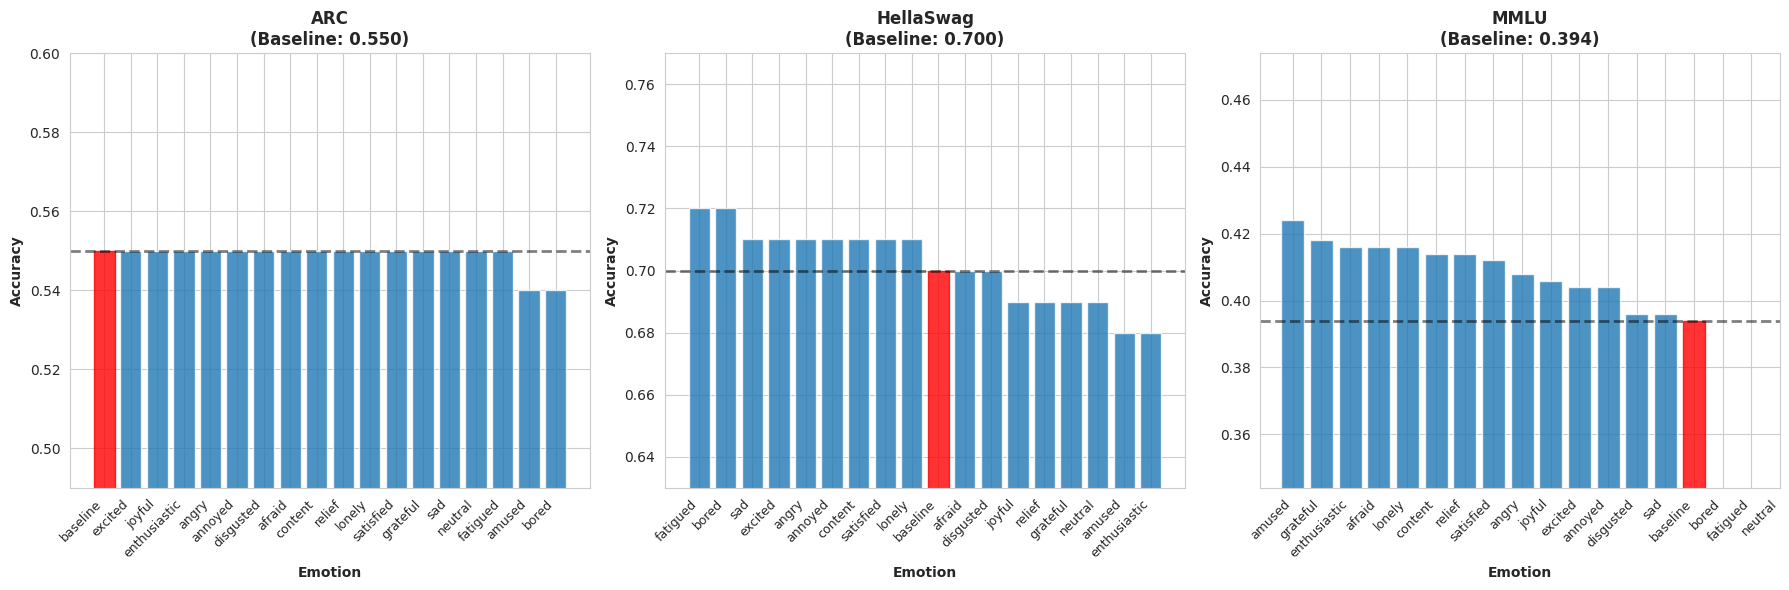


Summary Statistics:
             ARC  HellaSwag       MMLU
count  18.000000  18.000000  15.000000
mean    0.548889   0.701667   0.409200
std     0.003234   0.012485   0.009002
min     0.540000   0.680000   0.394000
25%     0.550000   0.690000   0.404000
50%     0.550000   0.705000   0.412000
75%     0.550000   0.710000   0.416000
max     0.550000   0.720000   0.424000


In [ ]:
# Plot all three datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = ['ARC', 'HellaSwag', 'MMLU']
for i, dataset in enumerate(datasets):
    data = df[dataset].sort_values(ascending=False)
    
    bars = axes[i].bar(range(len(data)), data.values, alpha=0.8)
    
    # Highlight baseline
    baseline_idx = data.index.tolist().index('baseline')
    bars[baseline_idx].set_color('red')
    
    # Baseline line
    baseline_val = data['baseline']
    axes[i].axhline(y=baseline_val, color='black', linestyle='--', linewidth=2, alpha=0.5)
    
    axes[i].set_title(f'{dataset}\n(Baseline: {baseline_val:.3f})', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Accuracy', fontweight='bold')
    axes[i].set_xlabel('Emotion', fontweight='bold')
    axes[i].set_xticks(range(len(data)))
    axes[i].set_xticklabels(data.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylim([min(data.values) - 0.05, max(data.values) + 0.05])

plt.tight_layout()
# plt.savefig('../visualizations/lm_eval/lm_eval_accuracy_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary Statistics:")
print(df.describe())

## 4. Delta from Baseline

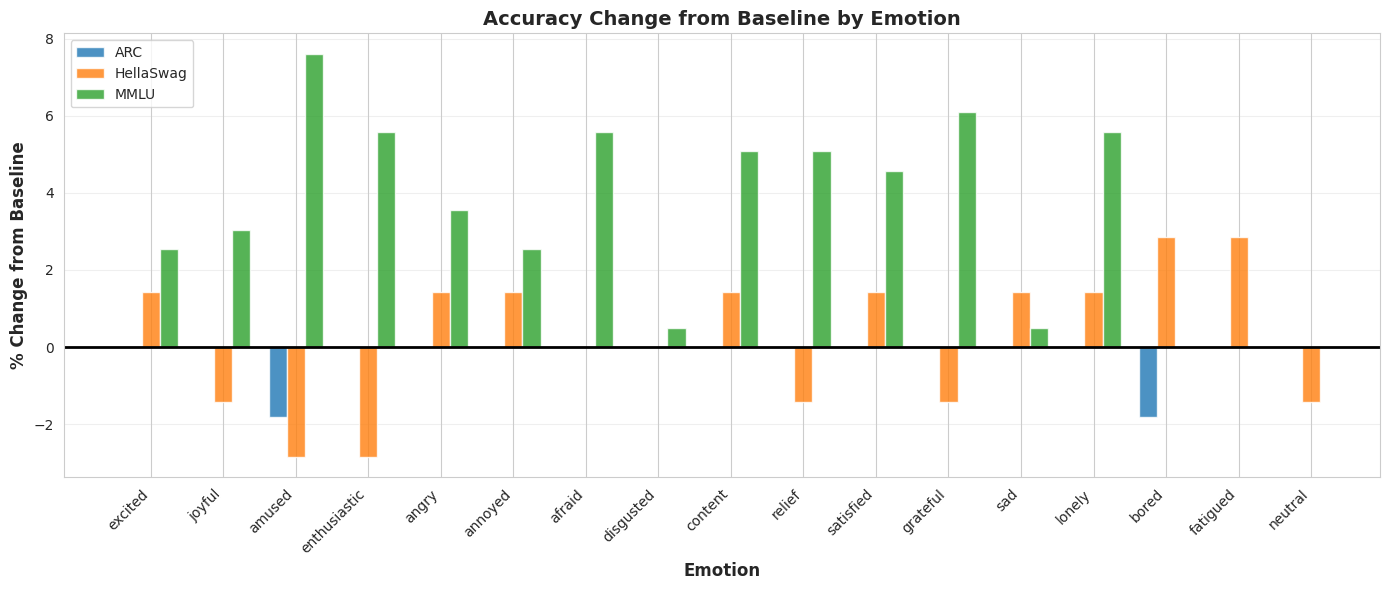


Delta from Baseline (% change):
                   ARC  HellaSwag      MMLU
excited       0.000000   1.428571  2.538071
joyful        0.000000  -1.428571  3.045685
amused       -1.818182  -2.857143  7.614213
enthusiastic  0.000000  -2.857143  5.583756
angry         0.000000   1.428571  3.553299
annoyed       0.000000   1.428571  2.538071
afraid        0.000000   0.000000  5.583756
disgusted     0.000000   0.000000  0.507614
content       0.000000   1.428571  5.076142
relief        0.000000  -1.428571  5.076142
satisfied     0.000000   1.428571  4.568528
grateful      0.000000  -1.428571  6.091371
sad           0.000000   1.428571  0.507614
lonely        0.000000   1.428571  5.583756
bored        -1.818182   2.857143       NaN
fatigued      0.000000   2.857143       NaN
neutral       0.000000  -1.428571       NaN

Maximum changes:
ARC: 0.00% (emotion: excited)
HellaSwag: 2.86% (emotion: bored)
MMLU: 7.61% (emotion: amused)


In [ ]:
# Calculate percentage change from baseline
baseline = df.loc['baseline']
delta_df = ((df - baseline) / baseline * 100)

# Remove baseline row
delta_df = delta_df.drop('baseline')

# Plot deltas
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(delta_df))
width = 0.25

bars1 = ax.bar(x - width, delta_df['ARC'], width, label='ARC', alpha=0.8)
bars2 = ax.bar(x, delta_df['HellaSwag'], width, label='HellaSwag', alpha=0.8)
bars3 = ax.bar(x + width, delta_df['MMLU'], width, label='MMLU', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.set_ylabel('% Change from Baseline', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Change from Baseline by Emotion', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(delta_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('../visualizations/lm_eval/lm_eval_delta_from_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDelta from Baseline (% change):")
print(delta_df)
print("\nMaximum changes:")
print(f"ARC: {delta_df['ARC'].max():.2f}% (emotion: {delta_df['ARC'].idxmax()})")
print(f"HellaSwag: {delta_df['HellaSwag'].max():.2f}% (emotion: {delta_df['HellaSwag'].idxmax()})")
print(f"MMLU: {delta_df['MMLU'].max():.2f}% (emotion: {delta_df['MMLU'].idxmax()})")

## 5. Variance Analysis

Dataset Sensitivity to Emotion:
           Variance   Std Dev  Range
ARC        0.000010  0.003234   0.01
HellaSwag  0.000156  0.012485   0.04
MMLU       0.000081  0.009002   0.03


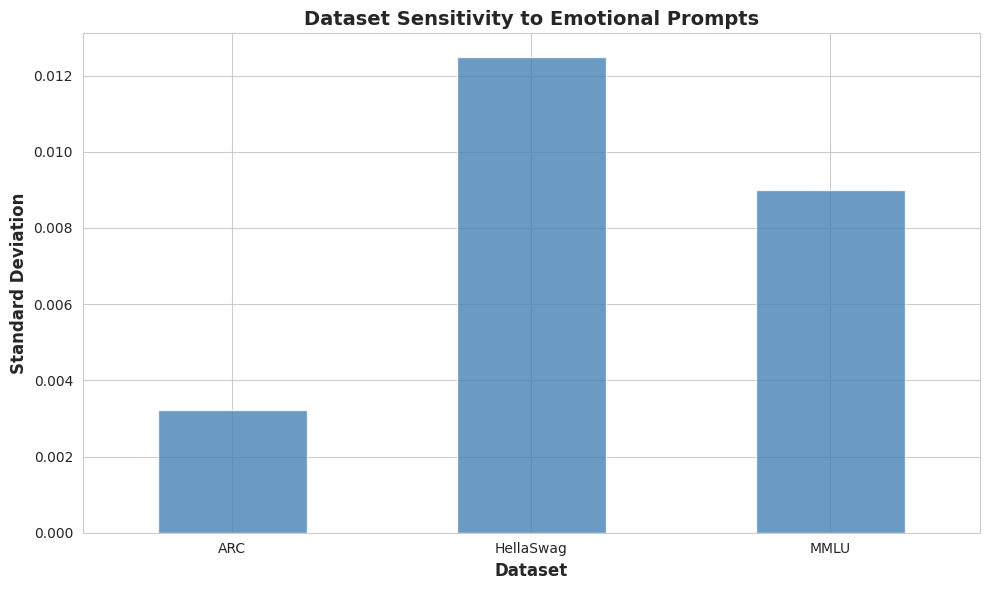

In [ ]:
# Which dataset shows most variance?
variance = df.var()
std_dev = df.std()
range_vals = df.max() - df.min()

variance_df = pd.DataFrame({
    'Variance': variance,
    'Std Dev': std_dev,
    'Range': range_vals
})

print("Dataset Sensitivity to Emotion:")
print(variance_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
variance_df['Std Dev'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_ylabel('Standard Deviation', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Dataset Sensitivity to Emotional Prompts', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
# plt.savefig('../visualizations/lm_eval/lm_eval_variance_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. MMLU Subject Breakdown

MMLU Subjects:
            baseline  excited  joyful  amused  enthusiastic  angry  annoyed  \
history         0.39     0.41    0.41    0.43          0.41   0.40     0.40   
philosophy      0.37     0.40    0.39    0.40          0.39   0.40     0.40   
psychology      0.49     0.47    0.51    0.51          0.51   0.50     0.49   
law             0.30     0.31    0.29    0.32          0.30   0.31     0.29   
health          0.42     0.43    0.43    0.46          0.47   0.43     0.44   

            afraid  disgusted  content  relief  satisfied  grateful   sad  \
history       0.41       0.40     0.40    0.39       0.38      0.41  0.39   
philosophy    0.40       0.38     0.42    0.38       0.40      0.42  0.40   
psychology    0.49       0.49     0.49    0.51       0.50      0.50  0.48   
law           0.32       0.28     0.32    0.33       0.30      0.29  0.29   
health        0.46       0.43     0.44    0.46       0.48      0.47  0.42   

            lonely  
history       0.40  
philo

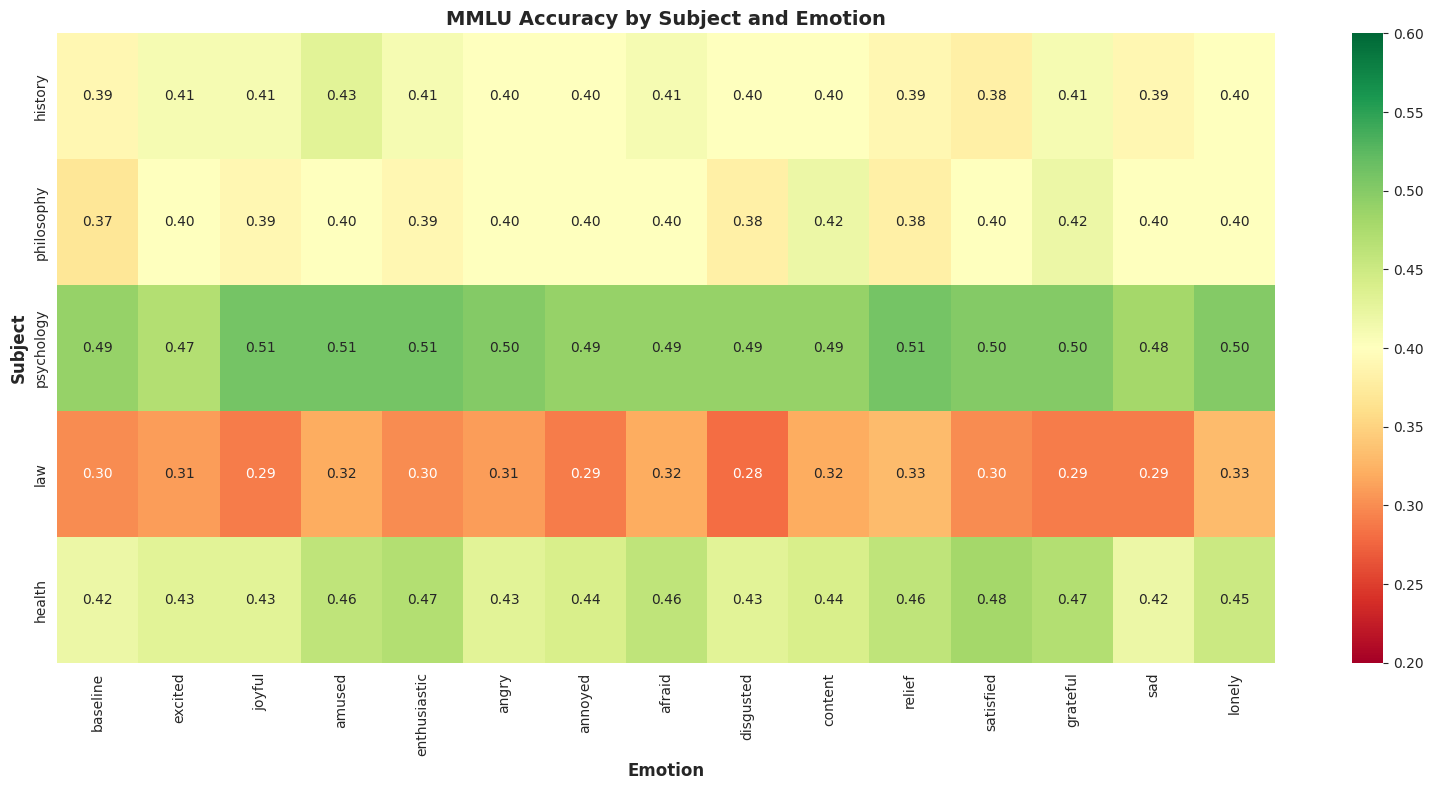


Subjects Most Affected (highest variance):
health        0.000383
law           0.000255
philosophy    0.000181
history       0.000146
psychology    0.000140
dtype: float64


In [ ]:
# Extract MMLU subjects
mmlu_subjects = {}
for emotion, results in mmlu_data.items():
    for subject, metrics in results.items():
        subject_name = metrics['alias']
        if subject_name not in mmlu_subjects:
            mmlu_subjects[subject_name] = {}
        mmlu_subjects[subject_name][emotion] = metrics['exact_match,custom-extract']

mmlu_df = pd.DataFrame(mmlu_subjects).T

print("MMLU Subjects:")
print(mmlu_df)

# Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(mmlu_df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.2, vmax=0.6, ax=ax)
ax.set_ylabel('Subject', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('MMLU Accuracy by Subject and Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/lm_eval/mmlu_subject_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Which subjects most affected?
subject_variance = mmlu_df.var(axis=1).sort_values(ascending=False)
print("\nSubjects Most Affected (highest variance):")
print(subject_variance)

## 7. Statistical Significance

In [8]:
# Test if differences are significant
# Note: With n=100 questions, SE ≈ 5%, so differences < 5% are within noise

print("="*60)
print("STATISTICAL TESTS")
print("="*60)

for dataset in ['ARC', 'HellaSwag', 'MMLU']:
    print(f"\n{dataset}:")
    
    # Get baseline and other emotions
    baseline_acc = df.loc['baseline', dataset]
    other_accs = df.drop('baseline')[dataset]
    
    # Assuming n=100 questions, SE ≈ sqrt(p(1-p)/n)
    n = 100
    baseline_se = np.sqrt(baseline_acc * (1 - baseline_acc) / n)
    
    print(f"  Baseline: {baseline_acc:.3f} ± {baseline_se:.3f}")
    print(f"  Range: {other_accs.min():.3f} - {other_accs.max():.3f}")
    print(f"  Difference: {other_accs.max() - baseline_acc:.3f}")
    
    # Is max difference > 1.96 * SE?
    z_score = abs(other_accs.max() - baseline_acc) / baseline_se
    print(f"  Z-score: {z_score:.2f} {'(significant)' if z_score > 1.96 else '(not significant)'}")

STATISTICAL TESTS

ARC:
  Baseline: 0.550 ± 0.050
  Range: 0.540 - 0.550
  Difference: 0.000
  Z-score: 0.00 (not significant)

HellaSwag:
  Baseline: 0.700 ± 0.046
  Range: 0.680 - 0.720
  Difference: 0.020
  Z-score: 0.44 (not significant)

MMLU:
  Baseline: 0.394 ± 0.049
  Range: 0.396 - 0.424
  Difference: 0.030
  Z-score: 0.61 (not significant)


## 8. Key Findings

In [9]:
print("="*60)
print("KEY FINDINGS: LM-EVAL RESULTS")
print("="*60)

print("\n1. MINIMAL VARIANCE")
print(f"   ARC range: {df['ARC'].max() - df['ARC'].min():.3f} ({(df['ARC'].max() - df['ARC'].min())*100:.1f}%)")
print(f"   HellaSwag range: {df['HellaSwag'].max() - df['HellaSwag'].min():.3f} ({(df['HellaSwag'].max() - df['HellaSwag'].min())*100:.1f}%)")
print(f"   MMLU range: {df['MMLU'].max() - df['MMLU'].min():.3f} ({(df['MMLU'].max() - df['MMLU'].min())*100:.1f}%)")

print("\n2. ALL WITHIN STANDARD ERROR")
print("   With n=100 questions, SE ≈ 5%")
print("   Observed differences (~2-4%) are within expected noise")

print("\n3. NO CLEAR EMOTIONAL PATTERN")
print("   No consistent emotion performs best/worst across datasets")

print("\n4. CONCLUSION")
print("   Multiple choice format is ROBUST to emotional prompts")
print("   → Motivated pivot to open-ended evaluation")
print("   → Open-ended shows MUCH stronger effects")

print("\n" + "="*60)

KEY FINDINGS: LM-EVAL RESULTS

1. MINIMAL VARIANCE
   ARC range: 0.010 (1.0%)
   HellaSwag range: 0.040 (4.0%)
   MMLU range: 0.030 (3.0%)

2. ALL WITHIN STANDARD ERROR
   With n=100 questions, SE ≈ 5%
   Observed differences (~2-4%) are within expected noise

3. NO CLEAR EMOTIONAL PATTERN
   No consistent emotion performs best/worst across datasets

4. CONCLUSION
   Multiple choice format is ROBUST to emotional prompts
   → Motivated pivot to open-ended evaluation
   → Open-ended shows MUCH stronger effects



## 9. Save Summary

In [ ]:
# Save summary statistics
summary = pd.DataFrame({
    'Dataset': ['ARC', 'HellaSwag', 'MMLU'],
    'Baseline': [df.loc['baseline', 'ARC'], df.loc['baseline', 'HellaSwag'], df.loc['baseline', 'MMLU']],
    'Mean': [df['ARC'].mean(), df['HellaSwag'].mean(), df['MMLU'].mean()],
    'Std': [df['ARC'].std(), df['HellaSwag'].std(), df['MMLU'].std()],
    'Min': [df['ARC'].min(), df['HellaSwag'].min(), df['MMLU'].min()],
    'Max': [df['ARC'].max(), df['HellaSwag'].max(), df['MMLU'].max()],
    'Range': [df['ARC'].max() - df['ARC'].min(), 
              df['HellaSwag'].max() - df['HellaSwag'].min(),
              df['MMLU'].max() - df['MMLU'].min()]
})

print("\nSummary:")
print(summary)

# summary.to_csv('../visualizations/lm_eval/lm_eval_summary.csv', index=False)
# print("\n✓ Saved to visualizations/lm_eval_summary.csv")


Summary:
     Dataset  Baseline      Mean       Std    Min    Max  Range
0        ARC     0.550  0.548889  0.003234  0.540  0.550   0.01
1  HellaSwag     0.700  0.701667  0.012485  0.680  0.720   0.04
2       MMLU     0.394  0.409200  0.009002  0.394  0.424   0.03

✓ Saved to visualizations/lm_eval_summary.csv
